# HealthConnect Clinic - Week 5 Analytics Report
### AnalystLab Africa Experience Lab | Data Analysis Track

**Central Project Question:** How can HealthConnect Clinic use data and Al to reduce missed appointment and improve the patient support experience?

## Part 1: Review of Week 4 Foundation

**Problem defined:** Understanding which patient, booking, and clinic-side factors are associated with appointment no-shows, and identifying KPIs the clinic can use to measure and address this problem.

**Week 4 approach:** Assessed data quality, identified 5 business questions and proposed 5 candidate KPIs linked to those questions, without yet calculating them.

**Recourses used:** HealthhConnect_Appointment_Data.csvv and the Data Dictionary.

**Key assumptions/limitations from Week 4:** The dataset lacks socioeconomic and clinical-severity data;missing values in distance/waiting time are small (1-2%) but need a handling decision; the cancelled class is small (-5%)

**Week 5 goal:** Move from identifying KPIs to actually calculating them, exploring relationships in the data, visualizing findings, and producing concrete business insights.

## Part 2: Data Preparation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

df = pd.read_csv('HealthConnect_Appointment_Data.csv')
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
df.head()

Rows: 5000, Columns: 18


,appointment_id,patient_id,gender,age,age_group,appointment_type,booking_date,appointment_date,appointment_day,appointment_time,booking_lead_days,previous_appointments,previous_no_shows,reminder_sent,reminder_channel,distance_to_clinic_km,waiting_time_minutes,appointment_outcome
0,HC-00001,P-1613,Female,39,35-44,Follow-up,2/6/2025,2/18/2025,Tuesday,Afternoon,12,2,0,Yes,WhatsApp,19.3,29.0,No-Show
1,HC-00002,P-0813,Male,31,25-34,Specialist Consultation,2/25/2026,2/27/2026,Friday,Morning,2,6,0,Yes,SMS,14.3,42.0,Attended
2,HC-00003,P-1366,Female,50,45-54,General Consultation,11/16/2025,12/24/2025,Wednesday,Morning,38,5,1,Yes,SMS,11.4,11.0,No-Show
3,HC-00004,P-1031,Male,59,55-64,Follow-up,7/18/2025,8/28/2025,Thursday,Evening,41,3,1,Yes,SMS,7.4,35.0,Attended
4,HC-00005,P-1458,Female,34,25-34,Follow-up,7/9/2025,8/25/2025,Monday,Afternoon,47,3,1,Yes,Email,5.6,27.0,No-Show


### Data Types and Structure Review

In [2]:
df.dtypes

appointment_id               str
patient_id                   str
gender                       str
age                        int64
age_group                    str
appointment_type             str
booking_date                 str
appointment_date             str
appointment_day              str
appointment_time             str
booking_lead_days          int64
previous_appointments      int64
previous_no_shows          int64
reminder_sent                str
reminder_channel             str
distance_to_clinic_km    float64
waiting_time_minutes     float64
appointment_outcome          str
dtype: object

The 'booking_date' and 'appointment_date' columns are currently stored as texts, not as actual dates. I'll convert them to proper date format so i can accurately work with time-based calculations (like booking lead time).

In [3]:
df['booking_date'] = pd.to_datetime(df['booking_date'], format='%m/%d/%Y')
df['appointment_date'] = pd.to_datetime(df['appointment_date'], format='%m/%d/%Y')

df[['booking_date', 'appointment_date']].dtypes

booking_date        datetime64[us]
appointment_date    datetime64[us]
dtype: object

### Missing Values Check

In [7]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})[missing > 0]

,missing_count,missing_pct
reminder_channel,1366,27.32
distance_to_clinic_km,90,1.80
waiting_time_minutes,60,1.20


### Duplicate Records Check

In [8]:
print("Fully duplicated rows:", df.duplicated().sum())
print("Duplicate appointment_id:", df['appointment_id'].duplicated().sum())

Fully duplicated rows: 0
Duplicate appointment_id: 0


### Data Preparation Summary

- Converted 'booking_date' and appointment_date' from text to proper date format to support accurate data-based calculations.
- No duplicate rows or duplicate rows or duplicate appointment IDs were found; each row represents a unique appointment.
- Missing values remain limted to three columns:
    - 'reminder_channel' (27.3% missing) - this is expected, since it's only recoreded when a reminder was actually sent. It will be treated as "no Reminder" rather than a data error.
    - 'distance_to_clinic_km' (1.8% missing) and 'waiting_time_minutes' (1.2% missing) - small enough that I will exclude these rows only when directly analyzing those specific variables, rather than dropping them from the whole dataset.

No values were removed or overwritten in the original dataset; any exclusions will be handled at the point of specific analysis, not globally.

In [9]:
df['reminder_channel'] = df['reminder_channel'].fillna('No Reminder')
df['reminder_channel'].value_counts()

reminder_channel
SMS            2000
No Reminder    1366
WhatsApp       1101
Email           533
Name: count, dtype: int64

## Exploratory Data Analysis

This section explores relationships between appointment outcomes (Attended, No-Show, Cancelled) and key patient, booking, and clinic-related factors.

### Reminder Channel vs. Appointment Outcome

In [10]:
pd.crosstab(df['reminder_channel'], df['appointment_outcome'], normalize='index').mul(100).round(1)

appointment_outcome,Attended,Cancelled,No-Show
reminder_channel,,,
Email,46.5,5.1,48.4
No Reminder,42.7,5.9,51.4
SMS,49.6,4.6,45.8
WhatsApp,44.6,5.6,49.8


**Interpretation:** Patients who received no reminder at all had the highest no-show rate (51.4%). Among those who did receive a reminder, SMS performed best (45.8% no-show rate), followed by Email (48.4%) and Whatsapp (49.8%). Thhis suggests reminders are generally associated with better attendance, and SMS in particular may be the clinic's most effective chanel; though this is a descriptive association, not proof of a direct cause-and-effect relationship.

### Booking Lead Time vs. Appointment Outcome

In [11]:
df['lead_time_band'] = pd.cut(df['booking_lead_days'],
                                bins=[-1, 7, 30, 60],
                                labels=['0-7 days', '8-30 days', '31-60 days'])

pd.crosstab(df['lead_time_band'], df['appointment_outcome'], normalize='index').mul(100).round(1)

appointment_outcome,Attended,Cancelled,No-Show
lead_time_band,,,
0-7 days,66.6,5.6,27.8
8-30 days,54.8,5.0,40.2
31-60 days,34.1,5.4,60.5


**Interpretation:** There is a clear relationship between booking lead time and no-show rate. Appointments booked 0-7 days in advance have a no-show rate of only 27.8%, while appoitments booked 31-60 days in advance have a no-show rate of 60.5%; more than double. This suggests that the longer the gap between booking and the actual appointment, the more likely a patient is to forget, deprioritize, or have a change in circumstances that causes them to miss it. This is one of the strongest patterns found so far and could be highly actionable for the clinic (e.g., sending extra reminders for appointents booked far in advance).

### Previous No-Show History vs. Appointment Outcome

In [12]:
df['had_prev_noshow'] = df['previous_no_shows'] > 0

pd.crosstab(df['had_prev_noshow'], df['appointment_outcome'], normalize='index').mul(100).round(1)

appointment_outcome,Attended,Cancelled,No-Show
had_prev_noshow,,,
False,50.5,6.0,43.5
True,40.4,4.2,55.4


**Interpretation:** Patients with at least one previous no-show have a no-show rate of 55.4%, compared to 43.5% for patients with a clean attendance history - a nearly 12 percentage point difference. This confirms that past behaviour is a meaningful signal: patients who have missed appointments before are considerably more likely to miss future ones too. This variable will likely be one of the most valuable predictors for the Data Science track's no-show prediction model.

### Distance to Clinic vs. Appointment Outcome

In [13]:
df['distance_band'] = pd.cut(df['distance_to_clinic_km'],
                               bins=[-1, 5, 15, 100],
                               labels=['0-5 km', '5-15 km', '15+ km'])

pd.crosstab(df['distance_band'], df['appointment_outcome'], normalize='index').mul(100).round(1)

appointment_outcome,Attended,Cancelled,No-Show
distance_band,,,
0-5 km,49.0,4.6,46.5
5-15 km,47.0,5.7,47.3
15+ km,41.0,4.9,54.1


**Interpretation:** Distance shows a mild but noticeable effect - patients living within 5 km of the clinic have a no-show rate of 46.5%, rising to 54.1% for those living 15+ km away. This suggests travel burden may contribute to missed appointments, though the effect is less dramatic than booking lead time or prior no-show history. This factor may be more useful for the clinic when combined with other variables (e.g., a patient who lives far away *and* booked far in advance may be especially high-risk).

### Previous Waiting Time vs. Appointment Outcome

In [14]:
df['waiting_time_band'] = pd.cut(df['waiting_time_minutes'],
                                   bins=[-1, 15, 30, 200],
                                   labels=['0-15 min', '16-30 min', '30+ min'])

pd.crosstab(df['waiting_time_band'], df['appointment_outcome'], normalize='index').mul(100).round(1)

appointment_outcome,Attended,Cancelled,No-Show
waiting_time_band,,,
0-15 min,47.3,5.7,47.1
16-30 min,45.0,5.8,49.2
30+ min,48.2,4.1,47.7


**Interpretation:** Unlike lead time or prior no-show history, previous waiting time shows little to no clear relationship with appointment outcome - no-show rates stay roughly the same (around 47-49%) across all waiting time bands. This suggests that, in this dataset, how long a patient previously aited does not meaningfully predict whether they'll miss a future appointment. This is a useful negative finidng; it means the clinic's resources may be better spent addressing lead time and reminder strategy rather than wait-time reduction if the specific goal is cutting no-shows.

### Appointment Type vs. Appointment Outcome

In [15]:
pd.crosstab(df['appointment_type'], df['appointment_outcome'], normalize='index').mul(100).round(1)

appointment_outcome,Attended,Cancelled,No-Show
appointment_type,,,
Diagnostic Test,45.9,4.4,49.7
Follow-up,43.3,5.4,51.2
General Consultation,48.3,5.1,46.6
Specialist Consultation,46.6,6.0,47.4


**Interpretation:** Appointment ttype shows a modest difference- follow up appointments have the highest no-show rate (51.2%), while General Consultations have the lowest (46.6%). This may suggest that patients place a higher priority on new or general concerns than on routine follow-ups, possibly because follow-ups feel less urgent once the original issue has been addressed. This is a similar effect than lead time or prior no-show gistory, but still worth flagging as a segment the clinic could target with tailored reminders.

### EDA Summary

Across the relationships explored, the strongest patterns associated with no-shows are:
1. **Booking lead time** - longer gaps between booking and appointment strongly increase no-show risk (27.8% → 60.5%).
2. **Prior no-show history** - patients with a previous no-show are considerably more likely to miss future appointments (55.4% vs. 43.5%).
3. **Reminders** - receiving a reminder (especially via SMS) is assoiciated with a lower no-show rate than receiving none.
4. **Distance to clinic** - a milder effect, with patients living farther away showing somewhat higher no-show rates.

Weaker or negligible relationship were found for:
- **Previous waiting time** - little to no difference in no-show rate across waiting time bands.
- **Apointment type** - a modest difference, with follow-ups showing slightly higher no-show rates than General Consultations.

These findings directly inform which KPIs are most worth calculating and tracking, covered in the next section.

## KPI Development

Based on the Week 4 candidate KPIs and the relationships explored in the EDA above, the following 5 KPIs have been selected for calculation, as they show the clearest and most actionable patterns.

### KPI 1: Overall No-Show Rate

**Definition:** The percentage of all scheduled appointents that result in a no-show.

**Why it matters:** This is the clinic's baseline measure of the scale of the missed-appointment problem - every other KPI is measured against this benchmark.

**Linked business question:** What is the overall no-show rate, and how does it vary across patient segments, appointment types, and time slots?

In [16]:
overall_no_show_rate = (df['appointment_outcome'] == 'No-Show').mean() * 100
print(f"Overall No-Show Rate: {overall_no_show_rate:.1f}%")

Overall No-Show Rate: 48.5%


**Interpretation:** Nearly half of all appointment (48.5%) end in a no-show. This confirms the business scenario's framing - missed appointments are not a minor inefficiency but a problem affecting close to half of all scheduled care, representing a major opportunity for the clinic to improve attendance through targeted intervention.

### KPI 2: Reminder Effectiveness Rate

**Definition:** The no-show rate compared across reminder channels (SMS, WhatsApp, Email, No Reminder).

**Why it matters:** This measures whether the clinic's current reminder system is working, and which channel is most effective - directly actionable for the clinic's operations.

**Linked business question:** Does sending a reminder - and which chaneel is used - relate to whether a patient attends?

In [17]:
reminder_effectiveness = df.groupby('reminder_channel')['appointment_outcome'].apply(
    lambda x: (x == 'No-Show').mean() * 100
).round(1).sort_values()

reminder_effectiveness

reminder_channel
SMS            45.8
Email          48.4
WhatsApp       49.8
No Reminder    51.4
Name: appointment_outcome, dtype: float64

**Interpretation:** SMS reminders show the lowest no-show rate (45.8%), while patients who received no reminder at all had the highest no-show rate (51.4%) - a gap of 5.6 percentage points. Email and WhatsApp fall in between. This suggests reminders are associated with meaningfully better attendance, and if the clinic must prioritize one channel, SMS currently shows the strongest association with attendance.

### KPI 3: Repeat No-Show Rate

**Definition:** The no-show rate for patients who have at least one previous no-show, compared to those with no prior no-show history.

**Why it matters:** This tests whether past behavior predicts future behavior - a key input for identifying high-risk patients the clinic could proactively target.

**Linked business question:** How much does a patient's past no-show history predict whether they'll miss a future appointment?

In [18]:
repeat_no_show_rate = df.groupby('had_prev_noshow')['appointment_outcome'].apply(
    lambda x: (x == 'No-Show').mean() * 100
).round(1)

repeat_no_show_rate

had_prev_noshow
False    43.5
True     55.4
Name: appointment_outcome, dtype: float64

**Interpretation:** Patients with a prior no-show have a no-show rate of 55.4%, nearly 12 percentage points higher than patients with no prior no-show history (43.5%). This confirms that past attendance behavior is one of the strongest available signals for predicting future no-shows, making it a high-priority variable for any future prediction model and a practical flag the clinic could use today to identify at-risk patients.

### KPI 4: No-Show Rate by Booking Lead Time Band

**Definition:** The no-show rate grouped into three booking lead time bands: 0-7 days, 8-30 days, and 31-60 days.

**Why it matters:** This identifies whether the timing of when an appointment is booked relative to when it occurs affects the likelihood of attendance - directly actionable through scheduling policy or targeted reminders.

**Linked business question:** Does booking lead time relate to the chance of a no-show?

In [19]:
lead_time_no_show = df.groupby('lead_time_band', observed=True)['appointment_outcome'].apply(
    lambda x: (x == 'No-Show').mean() * 100
).round(1)

lead_time_no_show

lead_time_band
0-7 days      27.8
8-30 days     40.2
31-60 days    60.5
Name: appointment_outcome, dtype: float64

**Interpretation:** This is the strongest pattern found in the entire analysis. No-show rate more than doubles from 27.8% for appointments booked 0-7 days in advance to 60.5% for appointments booked 31-60 days in advance. This suggests that the longer a patient waits between booking and their appointment, the more likely they are to forget or deprioritize it. This is a highly actionable finding - the clinic could introduce additional reminder touchpoints specifically for appointments booked far in advance.

### KPI 5: No-Show Rate by Distance to Clinic

**Definition:** The no-show rate grouped into three distance bands: 0-5 km, 5-15 km, and 15+ km.

**Why it matters:** This tests whether travel burden is a factor in missed appointments, which could inform whether the clinic should consider transport support or virtual options for distant patients.

**Linked business question:** Do access-related factors; specifically distance to the clinic, relate to no-show behavior?

In [20]:
distance_no_show = df.groupby('distance_band', observed=True)['appointment_outcome'].apply(
    lambda x: (x == 'No-Show').mean() * 100
).round(1)

distance_no_show

distance_band
0-5 km     46.5
5-15 km    47.3
15+ km     54.1
Name: appointment_outcome, dtype: float64

**Interpretation:** No-show rate rises from 46.5% for patients within 5 km of the clinic to 54.1% for patients living 15+ km away. While a real effect, this is milder than booking lead time or prior no-show history. This suggests distance is a contributing factor, and may be worth combining with other risk factors (e.g., a patient who lives far away *and* booked far in advance) to identify the highest-risk appointments, rather than relying on distance alone.

### KPI Summary

| KPI | Result | Strength of Effect |
|---|---|---|
| Overall No-Show Rate | 48.5% | Baseline |
| Reminder Effectiveness (SMS vs. None) | 45.8% vs. 51.4% | Moderate |
| Repeat No-Show Rate (prior no-show vs. none) | 55.4% vs. 43.5% | Strong |
| No-Show Rate by Lead Time (0-7 vs. 31-60 days) | 27.8% vs. 60.5% | Very Strong |
| No-Show Rate by Distance (0-5km vs. 15+km) | 46.5% vs. 54.1% | Mild |

Booking lead time and prior no-show history stand out as the two strongest, most actionable signals for the clinic to act on. Reminders (particularly SMS) show a moderate positive association with attendance. Distance shows a real but smaller effect.

## Visualizations / Analytical Dashboard

The charts below visualize the key findings from the EDA and KPI sections, focused on the patterns with the clearest business implications.

### Chart 1: Overall Appointment Outcome Distribution

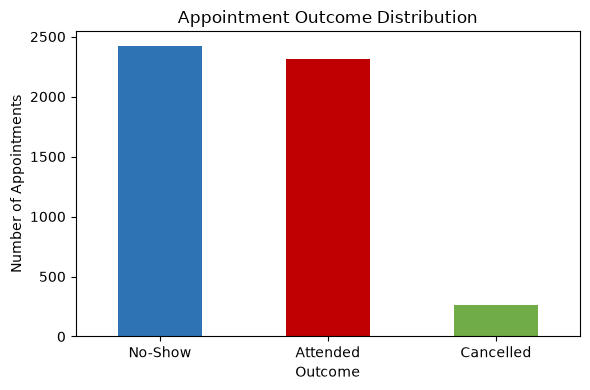

In [22]:
from pathlib import Path

outcome_counts = df['appointment_outcome'].value_counts()

plt.figure(figsize=(6,4))
outcome_counts.plot(kind='bar', color=['#2E74B5', '#C00000', '#70AD47'])
plt.title('Appointment Outcome Distribution')
plt.xlabel('Outcome')
plt.ylabel('Number of Appointments')
plt.xticks(rotation=0)
plt.tight_layout()
output_path = Path('../docs/chart1_outcome_distribution.png')
output_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()

**Observation:** The chart visually confirms the near-even split between Attended and No-Show appointments, with Cancelled appointments forming a small minority. This reinforces that no-shows are a large-scale, systemic issue rather than a rare occurrence.

### Chart 2: No-Show Rate by Booking Lead Time

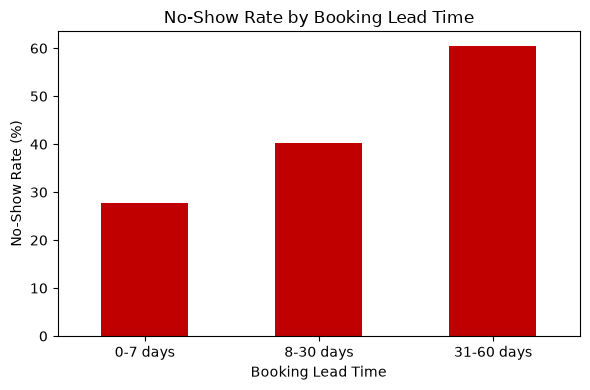

In [23]:
plt.figure(figsize=(6,4))
lead_time_no_show.plot(kind='bar', color='#C00000')
plt.title('No-Show Rate by Booking Lead Time')
plt.xlabel('Booking Lead Time')
plt.ylabel('No-Show Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()

output_path = Path('../docs/chart2_leadtime_noshow.png')
output_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()

**Observation:** This chart makes the lead-time effect immediately visible; the no-show rate climbs steeply as booking lead time increases, more than doubling from the shortest to the longest lead-time band. This is the single clearest, most actionable pattern in the dataset.

### Chart 3: No-Show Rate by Reminder Channel

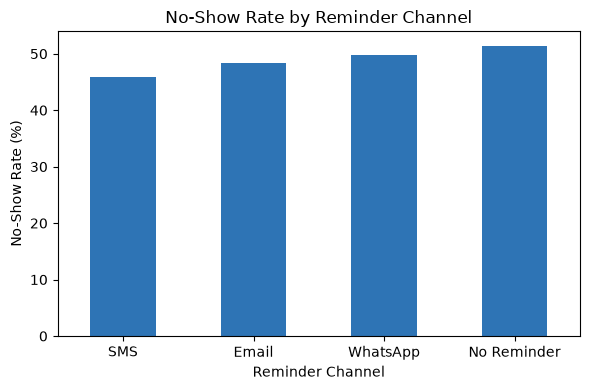

In [24]:
plt.figure(figsize=(6,4))
reminder_effectiveness.plot(kind='bar', color='#2E74B5')
plt.title('No-Show Rate by Reminder Channel')
plt.xlabel('Reminder Channel')
plt.ylabel('No-Show Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()

output_path = Path('../docs/chart3_reminder_noshow.png')
output_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()

**Observation:** SMS clearly stands out as the most effective reminder channel, with the lowest no-show rate, while patients receiving no reminder show the highest. This visual makes the case for prioritizing SMS reminders where possible.

### Chart 4: No-Show Rate by Prior No-Show History

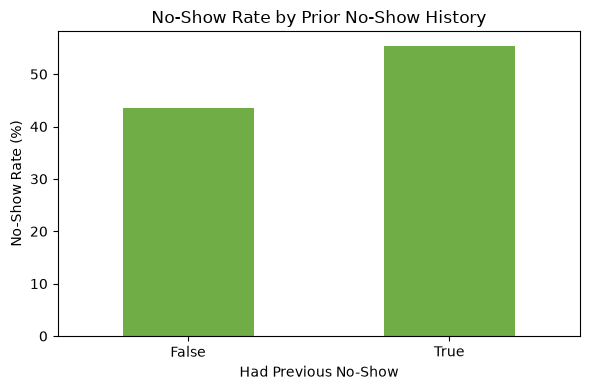

In [25]:
plt.figure(figsize=(6,4))
repeat_no_show_rate.plot(kind='bar', color='#70AD47')
plt.title('No-Show Rate by Prior No-Show History')
plt.xlabel('Had Previous No-Show')
plt.ylabel('No-Show Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()

output_path = Path('../docs/chart4_history_noshow.png')
output_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()

**Observation:** Patients with a history of missing appointments show a clearly higher no-show rate than those with a clean attendance record. This confirms that past behavior is a strong, visually obvious signal the clinic could use to flag at-risk patients proactively.

### Chart 5: No-Show Rate by Distance to Clinic

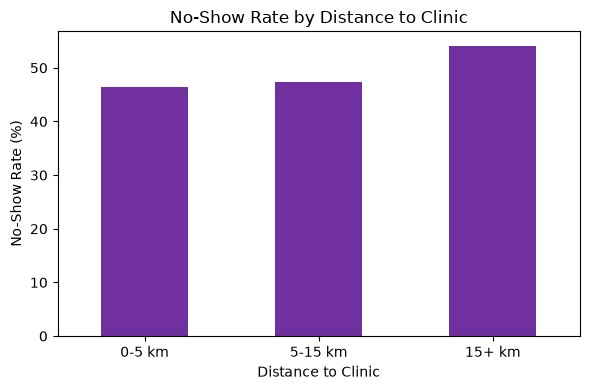

In [26]:
plt.figure(figsize=(6,4))
distance_no_show.plot(kind='bar', color='#7030A0')
plt.title('No-Show Rate by Distance to Clinic')
plt.xlabel('Distance to Clinic')
plt.ylabel('No-Show Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()

output_path = Path('../docs/chart5_distance_noshow.png')
output_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()

### Visualization Summary

The five charts above visually confirm the KPI findings: appointment outcomes are split nearly evenly between Attended and No-Show, and no-show risk rises sharply with longer booking lead times, prior no-show history, lack of reminders (especially lack of SMS), and greater distance from the clinic. These visuals give HealthConnect a clear, at-a-glance view of where attendance risk concentrates.

## Part 6: Business Insights and Recommendations

Based on the analysis above, the following insights and their implications for HealthConnect Clinic are proposed:

**1. Missed appointments are a large-scale problem, not an exception.**
Nearly half (48.5%) of all appointments end in a no-show. This means the clinic is likely losing close to half of its scheduled care capacity to missed appointments, a significant operational and financial concern worth prioritizing.

**2. Booking lead time is the single strongest predictor of no-shows.**
No-show rate rises from 27.8% (booked 0-7 days ahead) to 60.5% (booked 31-60 days ahead). *Implication:* The clinic should consider additional reminder touchpoints, not just one reminder close to the appointment, specifically for appointments booked far in advance.

**3. A patient's prior no-show history strongly predicts future no-shows.**
Patients with at least one previous no-show have a 55.4% no-show rate, compared to 43.5% for those with a clean history. *Implication:* The clinic could flag repeat no-show patients for extra reminder attention or a confirmation call before their appointment.

**4. SMS reminders are associated with the best attendance outcomes.**
Patients receiving SMS reminders had a 45.8% no-show rate, the lowest of any channel; while patients receiving no reminder had the highest (51.4%). *Implication:* If the clinic must prioritize resources, SMS should be the default reminder channel where patient contact information allows.

**5. Distance to the clinic has a real but moderate effect on attendance.**
No-show rate rises from 46.5% (within 5 km) to 54.1% (15+ km away). *Implication:* For patients living far from the clinic, offering telehealth/virtual consultation options (where appropriate) could reduce the impact of travel burden on attendance.


## Part 7: Limitations

- **Correlation, not causation:** All relationships identified (reminders, lead time, distance, history) are descriptive associations. They show patterns but do not prove that changing one factor (e.g., sending more reminders) will directly cause better attendance; a controlled test would be needed to confirm causal impact.
- **Missing contextual data:** The dataset does not include socioeconomic status, insurance/payment information, or clinical severity, all commonly cited real-world drivers of no-shows that this analysis cannot account for.
- **Small missingness handled by exclusion at point of use:** `distance_to_clinic_km` and `waiting_time_minutes` had small amounts of missing data (1-2%), which were left as-is and only excluded automatically during grouped calculations involving those specific columns.
- **Small Cancelled class:** Cancelled appointments make up only ~5% of the dataset, limiting how confidently any cancellation-specific patterns can be generalized.
- **Fictional/simulated dataset:** As this is a simulated dataset for the internship program, real-world messiness (e.g., inconsistent entry, larger data gaps) that a live clinic system would have is not present here.

## Part 8: Cross-Track Collaboration

**Track interacted with (conceptually):** Data Science

**Information/output exchanged:** The KPI findings from this analysis, particularly the strength of `previous_no_shows` and `booking_lead_days` as predictors of no-show outcome, are directly relevant to the Data Science track's Week 4 proposed target variable and feature list.

**Why this is relevant:** The Data Science track is building a predictive model for no-shows, and needs to know which features are most likely to carry real predictive signal before finalizing their feature set.

**What this could improve:** These findings suggest the Data Science track should prioritize `previous_no_shows`, `booking_lead_days`, and `reminder_channel` as high-value features, while treating `waiting_time_minutes` as lower priority given its weak relationship with outcome found here.